Total original track points: 16526
Track points 1960-2024: 16526
Track points Jun-Oct: 15667
Track points with wind_category 1-3: 15667

Track point counts per intensity category (before deduplication):
1    4260
2    6708
3    4699
Name: wind_category, dtype: int64

MJO active days (amplitude ≥ 1) records: 14550
Available MJO active dates: 14550

Track points matched to MJO active days: 8876
Deduplicated records (one per typhoon-day): 2301

Days per intensity category (after deduplication):
1     631
2    1024
3     646
Name: wind_category, dtype: int64

Days per typhoon category and phase group:
phase_group    Phases 1-2  Phases 3-4  Phases 5-6  Phases 7-8
wind_category                                                
1                     119          98         278         136
2                     179         134         475         236
3                      83         102         314         147

Total days per typhoon category:
wind_category
1     631
2    1024
3     646
dtype: 

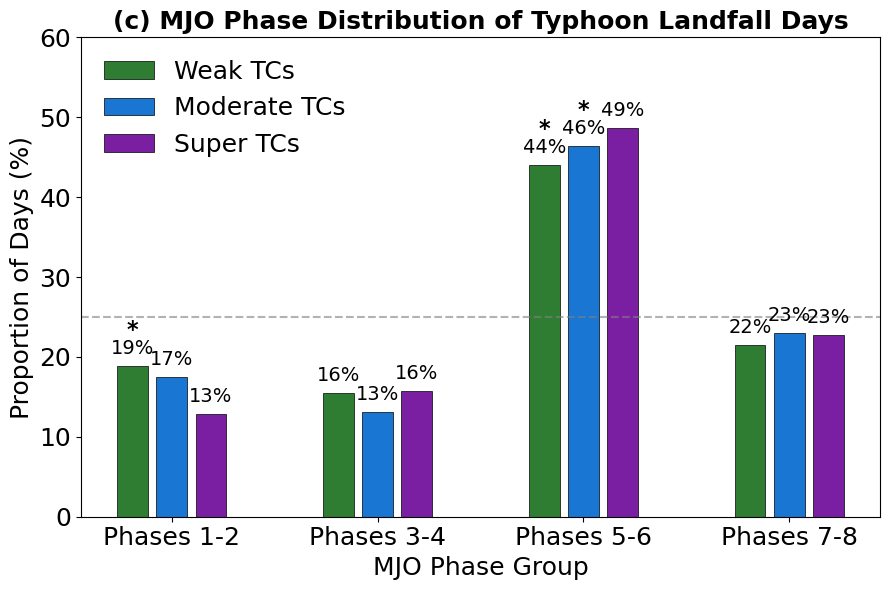

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ==================== Global path configuration ====================
TRACKS_PATH = "./typhoon_output/landfall_typhoons_tracks.csv"
MJO_PATH = "./ERA5 MJO (1950-2024).csv"

# Typhoon intensity category mapping (for colors and labels)
CATEGORY_MAP = {1: 'Weak TCs', 2: 'Moderate TCs', 3: 'Super TCs'}

COLOR_MAP = {'Weak TCs': '#2E7D32', 'Moderate TCs': '#1976D2', 'Super TCs': '#7B1FA2'}

# MJO phase group definitions
PHASE_GROUPS = {
    (1,2): 'Phases 1-2',
    (3,4): 'Phases 3-4',
    (5,6): 'Phases 5-6',
    (7,8): 'Phases 7-8'
}
GROUP_ORDER = ['Phases 1-2', 'Phases 3-4', 'Phases 5-6', 'Phases 7-8']

# %% [markdown]
# ### 3.1 Load and preprocess typhoon track data

# %%
# Read track data
tracks_df = pd.read_csv(TRACKS_PATH)
print(f"Total original track points: {len(tracks_df)}")

# Convert time format, extract date, year, month
tracks_df['TIME'] = pd.to_datetime(tracks_df['TIME'])
tracks_df['date'] = tracks_df['TIME'].dt.date
tracks_df['year'] = tracks_df['TIME'].dt.year
tracks_df['month'] = tracks_df['TIME'].dt.month

# Filter years 1960-2024
tracks_df = tracks_df[(tracks_df['year'] >= 1960) & (tracks_df['year'] <= 2024)]
print(f"Track points 1960-2024: {len(tracks_df)}")

# Filter months 6-10
tracks_df = tracks_df[tracks_df['month'].between(6,10)]
print(f"Track points Jun-Oct: {len(tracks_df)}")

# Filter typhoon intensity categories 1,2,3 (Storms, TCs, Super TCs)
tracks_df = tracks_df[tracks_df['wind_category'].isin([1,2,3])]
print(f"Track points with wind_category 1-3: {len(tracks_df)}")

# Show sample counts per category
print("\nTrack point counts per intensity category (before deduplication):")
print(tracks_df['wind_category'].value_counts().sort_index())

# %% [markdown]
# ### 3.2 Load and preprocess MJO data (keep only active days with amplitude ≥ 1)

# %%
mjo_df = pd.read_csv(MJO_PATH)
mjo_df['date'] = pd.to_datetime(mjo_df['date']).dt.date

# Time range 1960-2024
mjo_df = mjo_df[(mjo_df['date'] >= pd.to_datetime('1960-01-01').date()) & 
                (mjo_df['date'] <= pd.to_datetime('2024-12-31').date())]

# Keep only active events with amplitude ≥ 1
mjo_df = mjo_df[mjo_df['amplitude'] >= 1].copy()
print(f"\nMJO active days (amplitude ≥ 1) records: {len(mjo_df)}")

def phase_to_group(phase):
    """Map phases 1-8 to four groups"""
    if pd.isna(phase):
        return None
    p = int(phase)
    if p in [1,2]:
        return 'Phases 1-2'
    elif p in [3,4]:
        return 'Phases 3-4'
    elif p in [5,6]:
        return 'Phases 5-6'
    elif p in [7,8]:
        return 'Phases 7-8'
    else:
        return None

mjo_df['phase_group'] = mjo_df['phase'].apply(phase_to_group)
mjo_df = mjo_df.dropna(subset=['phase_group'])

# Build date -> phase group fast dictionary (only active days)
date_to_phase = pd.Series(mjo_df['phase_group'].values, index=mjo_df['date']).to_dict()
print(f"Available MJO active dates: {len(date_to_phase)}")

# %% [markdown]
# ### 3.3 Match dates and deduplicate (by typhoon code + date)

# %%
# Add phase group to each track point (keep only those matching MJO active days)
tracks_df['phase_group'] = tracks_df['date'].map(date_to_phase)
tracks_df = tracks_df.dropna(subset=['phase_group'])
print(f"\nTrack points matched to MJO active days: {len(tracks_df)}")

# Deduplicate by (typhoon code, date), keep first record (wind_category constant, any row works)
tracks_unique = tracks_df.drop_duplicates(subset=['chinese_code', 'date'])
print(f"Deduplicated records (one per typhoon-day): {len(tracks_unique)}")

# Show days per intensity category
print("\nDays per intensity category (after deduplication):")
print(tracks_unique['wind_category'].value_counts().sort_index())

# %% [markdown]
# ### 3.4 Group counts and compute percentages

# %%
# Group count by wind_category and phase_group
counts = tracks_unique.groupby(['wind_category', 'phase_group']).size().unstack(fill_value=0)
# Ensure all phase groups present (fill missing with 0)
counts = counts.reindex(columns=GROUP_ORDER, fill_value=0)
print("\nDays per typhoon category and phase group:")
print(counts)

# Total days per typhoon category
total_days = counts.sum(axis=1)
print("\nTotal days per typhoon category:")
print(total_days)

# Compute percentages (each row sums to 100%)
percentages = counts.div(total_days, axis=0) * 100
print("\nPercentage of days per phase group for each category (%):")
print(percentages.round(1))

# %% [markdown]
# ### 3.5 Plot bar chart

# Set up figure
fig, ax = plt.subplots(figsize=(9, 6))

# x-axis positions: four phase groups
x = np.arange(len(GROUP_ORDER))
width = 0.15          # bar width
gap = 0.08            # extra gap between bars
# Offsets for the three typhoon categories
offsets = [-width - gap/2, 0, width + gap/2]

# Define which bar indices (from 1, in draw order) to mark with stars
star_cols = [1, 3, 7]   # can be adjusted as needed

# Draw bars
categories = [1, 2, 3]  # order: Weak, Moderate, Super
col_counter = 1          # bar counter starting from 1
for i, cat in enumerate(categories):
    cat_name = CATEGORY_MAP[cat]
    # Percentage values for this category across phase groups
    pct_vals = percentages.loc[cat].values
    # Bar positions
    bar_positions = x + offsets[i]
    bars = ax.bar(bar_positions, pct_vals, width,
                  color=COLOR_MAP[cat_name],
                  edgecolor='black', linewidth=0.5,
                  label=cat_name)          # ✅ label for legend
    
    # Annotate each bar with percentage (keep 1 decimal if > 0)
    for bar, pct in zip(bars, pct_vals):
        if pct > 0:
            # Annotate percentage
            x_center = bar.get_x() + bar.get_width()/2
            y_base = bar.get_height() + 1
            ax.text(x_center, y_base, f'{pct:.0f}%', ha='center', va='bottom', fontsize=14)
            
            # If current bar index is in star_cols, add a star above the percentage
            if col_counter in star_cols:
                # Star position slightly above the percentage number (adjustable offset)
                y_star = y_base + 2
                ax.text(x_center, y_star, '*', ha='center', va='bottom',
                        fontsize=16, fontweight='bold', color='black')  # star style can be customized
            
            col_counter += 1   # increment counter
        else:
            # Even if percentage is 0, still increment counter to keep alignment
            col_counter += 1

# Set x-axis tick positions (center of each group)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER, fontsize=18)

# Add 25% black dashed reference line
ax.axhline(y=25, color='gray', alpha=0.6, linestyle='--', linewidth=1.5, label='_nolegend_')

# Axis labels and title
ax.set_xlabel('MJO Phase Group', fontsize=18)
ax.set_ylabel('Proportion of Days (%)', fontsize=18)
ax.set_title('(c) MJO Phase Distribution of Typhoon Landfall Days',
             fontsize=18, fontweight='bold')

# Add legend
ax.legend(['Weak TCs', 'Moderate TCs', 'Super TCs'], fontsize=18, loc='upper left', frameon=False)

# y-axis range (leave room for annotations and stars)
ax.set_ylim(0, 60)   # slightly higher to avoid clipping stars

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

# Remove grid
ax.grid(False)

for spine in ax.spines.values():
    spine.set_color('black')
    
plt.tight_layout()
plt.savefig('1c.png', dpi=600, bbox_inches='tight')
plt.show()